# Pharmaceutical Sales Data Analysis

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Loading


In [2]:
df=pd.read_csv('data/salesdaily.csv')
df

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


In [3]:
df.shape

(2106, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


## Data Cleaning

In [6]:
df.isna().sum()

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='object')

## Question 1

In [9]:
#1. What are the total sales quantities for each drug category (ATC code)?
total_sales=df[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06']].sum()
total_sales = total_sales.sort_values(ascending=False)

Text(0, 0.5, 'DRUG CATEGORY')

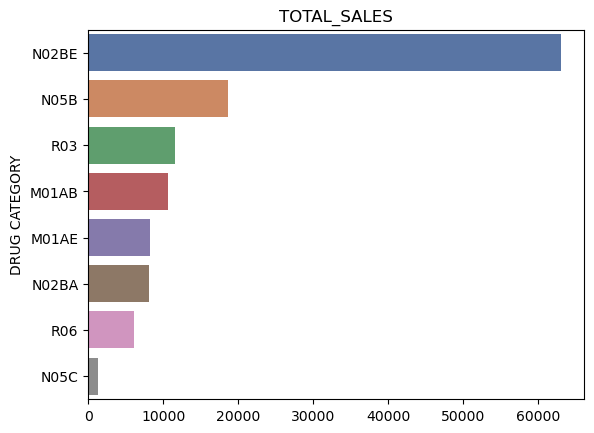

In [10]:
sns.barplot(y=total_sales.index,x=total_sales.values,palette='deep')
plt.title('TOTAL_SALES')
plt.ylabel('DRUG CATEGORY')

N02BE has the highest total sales among all drug categories.
N05C has the lowest total sales.
There is a significant difference between the highest and lowest selling categories.

## Question 2

In [ ]:
#2Which individual drug brands have the highest total sales?


The dataset does not contain individual drug brand names.
Only ATC drug category codes are available.
Therefore, brand-level sales analysis cannot be performed.

In [12]:
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE',
             'N05B', 'N05C', 'R03', 'R06']

## Question 3

In [13]:
#3Which three drugs have the highest sales in January 2015, July 2016, September 2017.
jan_2015_top3=df[(df['Year']==2015) & (df['Month']==1)][['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06']].sum()
jan_2015_top3=jan_2015_top3.sort_values(ascending=False).head(3).round(2)


In [14]:
jul_2016_top3=df[(df['Year']==2016) & (df['Month']==7)][drug_cols].sum()
jul_2016_top3=jul_2016_top3.sort_values(ascending=False).head(3).round(2)

In [15]:
sept_2017_top3=df[(df['Year']==2017) & (df['Month']==9)][drug_cols].sum()
sept_2017_top3=sept_2017_top3.sort_values(ascending=False).head(3).round(2)

In [16]:
print("January 2015")
print(jan_2015_top3)

print("\nJuly 2016")
print(jul_2016_top3)

print("\nSeptember 2017")
print(sept_2017_top3)

January 2015
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

July 2016
N02BE    652.36
N05B     240.00
M01AB    194.53
dtype: float64

September 2017
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


The top-selling drug categories varied across the selected periods.
N02BE consistently appeared among the highest-selling categories.

## Question 4

In [22]:
#4.Which drug has sold the most often in 2017? 


In [18]:
most_sold_2017=df[df['Year']==2017][drug_cols].sum().round(2)
most_sold_2017=most_sold_2017.sort_values(ascending=False).head(1)
print(most_sold_2017)

N02BE    9258.8
dtype: float64


The highest-selling drug category in 2017 was N02BE with total sales of 9258.8 units.

## Question 5

In [19]:
#5.Which drug category has the highest average daily sales?
highest_daily_sales=df[drug_cols].mean().round(2)
highest_daily_sales=highest_daily_sales.sort_values(ascending=False).head(1)
highest_daily_sales

N02BE    29.92
dtype: float64

## Question 6

In [23]:
#6.Are respiratory drugs (R03) sold more during specific months?
R03_sold=df.groupby('Month')['R03'].sum()


<Axes: xlabel='Month'>

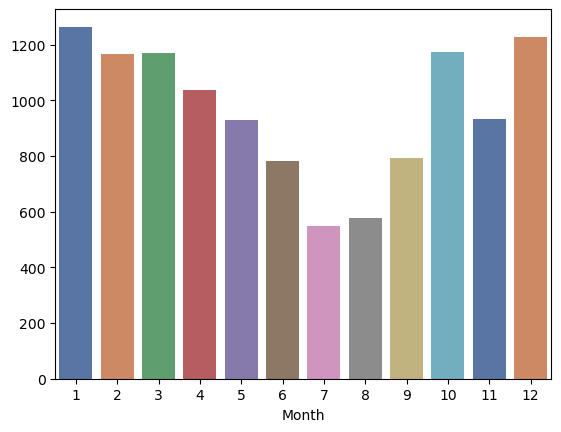

In [24]:
sns.barplot(x=R03_sold.index,y=R03_sold.values,palette='deep')